# Chunk-Level XGBoost — Crossed Random Effects (Worker + Task)

Extends `random_intercept_chunk_level_oe.ipynb` by adding a **task-level random effect**
alongside the worker-level random effect.

**Model:** `y_ij = mu + b_j (worker) + a_i (task) + e_ij`

**Why add task effects?**
The worker-only model estimates `b_j` after controlling for measured task features
(Weight, Cube, Quantity etc.). But those features may not fully explain task difficulty.
If a worker consistently gets harder products, their `b_j` absorbs that task difficulty
and looks artificially high — they appear slower than they actually are.
Adding `a_i` (task random effect on ProductID) pulls out unmeasured product-specific
difficulty, leaving `b_j` as a cleaner estimate of true worker speed.

**Why ProductID?**
LocationID is already well-captured by Aisle_group and Level_group fixed effects.
ProductID captures residual product difficulty that Weight, Cube, and Quantity
don't fully explain. Partial pooling handles sparse products automatically.

**Sequential estimation (no pymer4/R required):**
statsmodels MixedLM only supports one grouping factor. We approximate the crossed
model sequentially:
1. Fit worker random intercepts on raw pick times → `worker_effect`
2. Subtract worker effects to get worker-adjusted residuals
3. Fit product random intercepts on those residuals → `task_effect`

**Four scenarios compared:**
1. `Baseline` — no worker or task features
2. `+ Worker` — worker random intercept only (your current model)
3. `+ Task` — task random intercept only
4. `+ Worker + Task` — both crossed random intercepts

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("/Users/betsyfrdmn/Lucas_Systems_Capstone_Project/data/processed")
WAREHOUSE    = "OE"
WORKCODES    = ["10", "20", "30"]
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026

## Helper Functions
Identical to `random_intercept_chunk_level_oe.ipynb` so results are directly comparable.

In [2]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=str(workcode)
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    distance_num = ["Travel_Distance", "log_travel_distance"]
    distance_cat = ["same_aisle", "same_location", "diff_level"]
    features = [f for f in features_all if f not in distance_num + distance_cat]
    cat_cols = [c for c in cat_cols_all if c not in distance_cat]

    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days  = sorted(df["date"].dropna().unique())
    n_test    = max(1, int(round(len(all_days) * test_ratio)))
    test_days = all_days[-n_test:]
    train_df  = df[df["date"] < test_days[0]].copy()
    test_df   = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def make_test_blocks(test_df, block_size=50):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks = []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.reset_index()
        for start in range(0, len(g) - block_size + 1, block_size):
            chunk = g.iloc[start:start + block_size]
            if len(chunk) == block_size:
                blocks.append({
                    "BlockID": f"{uid}_{day}_{start // block_size}",
                    "UserID":  uid,
                    "date":    day,
                    "indices": chunk["index"].tolist()
                })
    return blocks


def eval_blocks(blocks, actual_series, pred_series):
    actual_blocks = [actual_series.loc[b["indices"]].sum() for b in blocks]
    pred_blocks   = [pred_series.loc[b["indices"]].sum()   for b in blocks]
    mae = mean_absolute_error(actual_blocks, pred_blocks)
    r2  = r2_score(actual_blocks, pred_blocks)
    return mae, r2, actual_blocks, pred_blocks

## Step 1: Sequential Crossed Random Effects Estimation

**Step 1a:** `Time_Delta_sec ~ 1 + (1|UserID)` → `worker_effect` b_j  
**Step 1b:** worker-adjusted residuals = `Time_Delta_sec - worker_effect`  
**Step 1c:** `residual ~ 1 + (1|ProductID)` → `task_effect` a_i  

Both estimated on training data only — no leakage.  
Unseen workers or products at test time get effect = 0 (grand mean fallback).

In [3]:
def estimate_crossed_effects(train_df):
    """
    Sequential approximation of crossed random intercepts.
    Returns:
      worker_effects : DataFrame [UserID, worker_effect]
      task_effects   : DataFrame [ProductID, task_effect]
    """
    df_re = train_df[["UserID", "ProductID", "Time_Delta_sec"]].dropna().copy()
    df_re["UserID"]    = df_re["UserID"].astype(str)
    df_re["ProductID"] = df_re["ProductID"].astype(str)

    n_workers  = df_re["UserID"].nunique()
    n_products = df_re["ProductID"].nunique()
    print(f"  Workers: {n_workers} | Unique products: {n_products}")

    # Step 1a: Worker random intercept
    worker_result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    worker_icc = (
        worker_result.cov_re.values[0][0] /
        (worker_result.cov_re.values[0][0] + worker_result.scale)
    )
    print(f"  [Worker] Grand mean: {worker_result.fe_params['Intercept']:.1f}s | "
          f"SD: {np.sqrt(worker_result.cov_re.values[0][0]):.1f}s | ICC: {worker_icc:.3f}")

    worker_effects = pd.DataFrame({
        "UserID":        list(worker_result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in worker_result.random_effects.values()]
    })

    # Step 1b: Worker-adjusted residuals
    df_re = df_re.merge(worker_effects, on="UserID", how="left")
    df_re["worker_effect"] = df_re["worker_effect"].fillna(0.0)
    df_re["resid"] = df_re["Time_Delta_sec"] - df_re["worker_effect"]

    # Step 1c: Product random intercept on worker-adjusted residuals
    if n_products < 2:
        print("  [Task] Not enough products — skipping")
        task_effects = pd.DataFrame({
            "ProductID":   df_re["ProductID"].unique(),
            "task_effect": 0.0
        })
    else:
        try:
            task_result = smf.mixedlm(
                "resid ~ 1", data=df_re, groups=df_re["ProductID"]
            ).fit(reml=True, disp=False)

            task_icc = (
                task_result.cov_re.values[0][0] /
                (task_result.cov_re.values[0][0] + task_result.scale)
            )
            print(f"  [Task]   Product SD: {np.sqrt(task_result.cov_re.values[0][0]):.1f}s | "
                  f"ICC: {task_icc:.3f}")

            task_effects = pd.DataFrame({
                "ProductID":   list(task_result.random_effects.keys()),
                "task_effect": [float(v.iloc[0]) for v in task_result.random_effects.values()]
            })

        except Exception as e:
            print(f"  [Task] Failed ({e}) — using zero task effects")
            task_effects = pd.DataFrame({
                "ProductID":   df_re["ProductID"].unique(),
                "task_effect": 0.0
            })

    return worker_effects, task_effects

## Step 2: Main Loop — Train, Predict, Evaluate at Chunk Level

In [4]:
all_block_results = []
all_block_detail  = []

xgb_params = dict(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

for wc in WORKCODES:
    print(f"\n{'='*55}")
    print(f"WorkCode {wc}")
    print(f"{'='*55}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)

    train_df, test_df, test_days = split_by_days(df_wc)
    print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")

    train_df["ProductID"] = train_df["ProductID"].astype(str)
    test_df["ProductID"]  = test_df["ProductID"].astype(str)

    # --------------------------------------------------
    # Estimate crossed effects on training data only
    # --------------------------------------------------
    print("  Fitting crossed random effects (sequential)...")
    worker_effects, task_effects = estimate_crossed_effects(train_df)

    # Join worker effects — unseen workers get 0
    train_df = train_df.merge(worker_effects, on="UserID",    how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID",    how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Join task effects — unseen products get 0
    train_df = train_df.merge(task_effects, on="ProductID", how="left")
    test_df  = test_df.merge(task_effects,  on="ProductID", how="left")
    train_df["task_effect"] = train_df["task_effect"].fillna(0.0)
    test_df["task_effect"]  = test_df["task_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # --------------------------------------------------
    # Feature sets
    # --------------------------------------------------
    cats_clean  = [c for c in cat_cols  if c != "efficient_user"]
    feats_clean = [f for f in features  if f != "efficient_user"]

    scenarios = {
        "Baseline":        feats_clean,
        "+ Worker":        feats_clean + ["worker_effect"],
        "+ Task":          feats_clean + ["task_effect"],
        "+ Worker + Task": feats_clean + ["worker_effect", "task_effect"],
    }

    test_preds = {}
    for label, feats in scenarios.items():
        X_train, X_test = make_X(train_df, test_df, feats, cats_clean)
        model = XGBRegressor(**xgb_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        test_preds[label] = pd.Series(preds, index=test_df.index)

    # --------------------------------------------------
    # Build blocks and evaluate
    # --------------------------------------------------
    blocks = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    print(f"  Blocks of size {BLOCK_SIZE}: {len(blocks)}")

    for label, pred_series in test_preds.items():
        mae, r2, actual_b, pred_b = eval_blocks(blocks, y_test, pred_series)
        all_block_results.append({
            "WorkCode":     wc,
            "Model":        label,
            "n_blocks":     len(blocks),
            "mae":          round(mae, 3),
            "mae_per_task": round(mae / BLOCK_SIZE, 3),
            "r2":           round(r2, 4),
        })

    for b in blocks:
        row = {
            "BlockID":     b["BlockID"],
            "UserID":      b["UserID"],
            "date":        b["date"],
            "WorkCode":    wc,
            "actual_time": y_test.loc[b["indices"]].sum(),
        }
        for label, pred_series in test_preds.items():
            row[label] = pred_series.loc[b["indices"]].sum()
        all_block_detail.append(row)

block_results_df = pd.DataFrame(all_block_results)
block_detail_df  = pd.DataFrame(all_block_detail)
print("\nDone.")


WorkCode 10
Train rows: 3599 | Test rows: 483
  Fitting crossed random effects (sequential)...
  Workers: 16 | Unique products: 2105
  [Worker] Grand mean: 83.8s | SD: 12.4s | ICC: 0.043
  [Task]   Product SD: 18.7s | ICC: 0.101
  Blocks of size 50: 6

WorkCode 20
Train rows: 18310 | Test rows: 3024
  Fitting crossed random effects (sequential)...
  Workers: 23 | Unique products: 1292


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  [Worker] Grand mean: 39.2s | SD: 11.1s | ICC: 0.034
  [Task]   Product SD: 24.5s | ICC: 0.161
  Blocks of size 50: 55

WorkCode 30
Train rows: 58434 | Test rows: 6864
  Fitting crossed random effects (sequential)...
  Workers: 37 | Unique products: 4196
  [Worker] Grand mean: 60.9s | SD: 22.4s | ICC: 0.210
  [Task]   Product SD: 17.9s | ICC: 0.164
  Blocks of size 50: 123

Done.


## Step 3: Results Table

In [5]:
print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks\n")
display(
    block_results_df
    .sort_values(["WorkCode", "mae_per_task"])
    .reset_index(drop=True)
)

Warehouse: OE | Block size: 50 tasks



,WorkCode,Model,n_blocks,mae,mae_per_task,r2
0,10,+ Worker,6,563.426,11.269,0.3500
1,10,+ Worker + Task,6,658.443,13.169,0.2443
2,10,Baseline,6,977.364,19.547,-0.6806
3,10,+ Task,6,1067.935,21.359,-0.9895
4,20,+ Worker + Task,55,243.691,4.874,0.7853
5,20,+ Worker,55,266.289,5.326,0.7505
6,20,+ Task,55,316.245,6.325,0.6020
7,20,Baseline,55,335.637,6.713,0.5668
8,30,+ Worker,123,263.168,5.263,0.5786
9,30,+ Worker + Task,123,281.425,5.629,0.5052


## Step 4: Head-to-Head Comparison

Key questions to answer from this table:
- Does `+ Task` add anything beyond `+ Worker`? → incremental value of task effects
- Does `+ Worker + Task` beat `+ Worker` alone? → does separating confounding help?
- How does `+ Task` alone compare to `+ Worker` alone? → which effect is stronger?

In [6]:
rows = []
for wc in WORKCODES:
    wc_df = block_results_df[block_results_df["WorkCode"] == wc].set_index("Model")

    def get_mae(label):
        return wc_df.loc[label, "mae_per_task"] if label in wc_df.index else float("nan")

    def get_r2(label):
        return wc_df.loc[label, "r2"] if label in wc_df.index else float("nan")

    mae_base = get_mae("Baseline")
    mae_w    = get_mae("+ Worker")
    mae_t    = get_mae("+ Task")
    mae_wt   = get_mae("+ Worker + Task")

    def pct(a, b):
        return round((a - b) / a * 100, 2) if a > 0 and not np.isnan(a) else None

    rows.append({
        "WorkCode":                    wc,
        "Baseline MAE/task (s)":       mae_base,
        "+ Worker MAE/task (s)":       mae_w,
        "+ Task MAE/task (s)":         mae_t,
        "+ Worker + Task MAE/task (s)": mae_wt,
        "Worker gain vs Base (%)": pct(mae_base, mae_w),
        "Task gain vs Base (%)": pct(mae_base, mae_t),
        "Both gain vs Worker (%)": pct(mae_w, mae_wt),
    })

display(pd.DataFrame(rows))

,WorkCode,Baseline MAE/task (s),+ Worker MAE/task (s),+ Task MAE/task (s),+ Worker + Task MAE/task (s),Worker gain vs Base (%),Task gain vs Base (%),Both gain vs Worker (%)
0,10,19.547,11.269,21.359,13.169,42.35,-9.27,-16.86
1,20,6.713,5.326,6.325,4.874,20.66,5.78,8.49
2,30,6.655,5.263,6.633,5.629,20.92,0.33,-6.95


## Step 5: Did Task Effects Change the Worker Estimates?

If task effects absorb difficulty that was bleeding into worker estimates,
the `worker_effect` values should shift between the worker-only and crossed models.
A positive shift means the worker looks faster once task difficulty is controlled —
their apparent slowness was partly due to harder task assignments.
A near-zero mean shift means task assignment bias was minimal.

In [7]:
# Run on WC30 training data — most data, most reliable estimates
df_wc30, _, _ = load_engineered_data(WAREHOUSE, "30", MAX_TIME)
train30, _, _ = split_by_days(df_wc30)
train30["ProductID"] = train30["ProductID"].astype(str)

# Worker-only estimates
df_w = train30[["UserID", "Time_Delta_sec"]].dropna().copy()
res_w = smf.mixedlm(
    "Time_Delta_sec ~ 1", data=df_w, groups=df_w["UserID"]
).fit(reml=True, disp=False)
worker_only = pd.DataFrame({
    "UserID":      list(res_w.random_effects.keys()),
    "worker_only": [float(v.iloc[0]) for v in res_w.random_effects.values()]
})

# Crossed estimates
worker_crossed, _ = estimate_crossed_effects(train30)
worker_crossed = worker_crossed.rename(columns={"worker_effect": "worker_crossed"})

# Compare
comp = worker_only.merge(worker_crossed, on="UserID", how="inner")
comp["shift"]     = comp["worker_crossed"] - comp["worker_only"]
comp["abs_shift"] = comp["shift"].abs()

print("Workers whose estimates shifted most when task effects were added (WC30):")
print("Positive shift = worker looks faster once product difficulty is separated")
print("Negative shift = worker looks slower once product difficulty is separated\n")
display(
    comp.sort_values("abs_shift", ascending=False)
    .head(10)
    .round(3)
    .reset_index(drop=True)
)
print(f"\nMean absolute shift: {comp['abs_shift'].mean():.2f}s")
print("Small mean shift = worker estimates were already clean in the worker-only model.")
print("Large mean shift = task assignment bias was inflating/deflating worker estimates.")

  Workers: 37 | Unique products: 4196
  [Worker] Grand mean: 60.9s | SD: 22.4s | ICC: 0.210
  [Task]   Product SD: 17.9s | ICC: 0.164
Workers whose estimates shifted most when task effects were added (WC30):
Positive shift = worker looks faster once product difficulty is separated
Negative shift = worker looks slower once product difficulty is separated



,UserID,worker_only,worker_crossed,shift,abs_shift
0,143,-17.297,-17.297,0.0,0.0
1,471,-17.150,-17.150,0.0,0.0
2,475,16.687,16.687,0.0,0.0
3,476,16.361,16.361,0.0,0.0
4,479,-11.281,-11.281,0.0,0.0
5,480,-21.171,-21.171,0.0,0.0
6,484,-18.589,-18.589,0.0,0.0
7,488,-19.567,-19.567,0.0,0.0
8,494,-20.542,-20.542,0.0,0.0
9,496,-15.251,-15.251,0.0,0.0



Mean absolute shift: 0.00s
Small mean shift = worker estimates were already clean in the worker-only model.
Large mean shift = task assignment bias was inflating/deflating worker estimates.


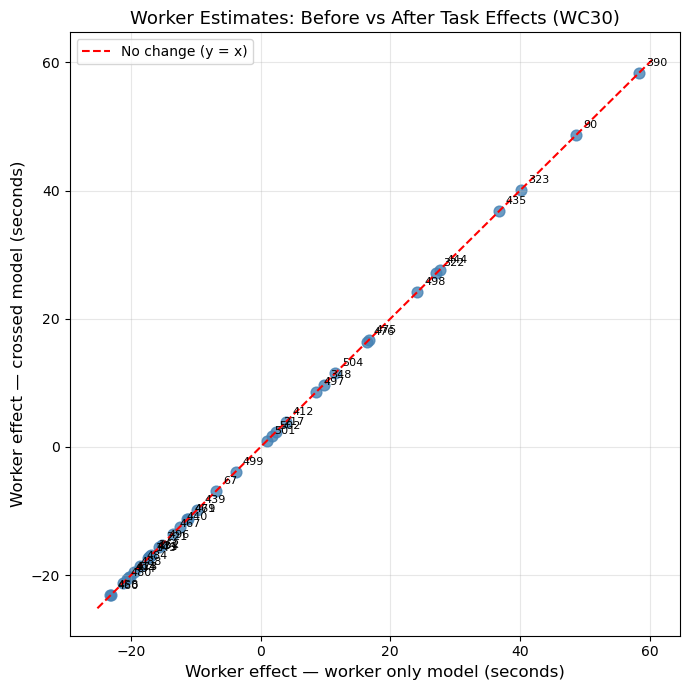

Mean absolute shift: 0.00s
Max shift: 0.00s (Worker 143)
Correlation between estimates: 1.0000


In [8]:
# Re-use comp DataFrame from Step 5
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(comp["worker_only"], comp["worker_crossed"], 
           s=60, alpha=0.8, color="steelblue")

# Annotate each point with UserID
for _, row in comp.iterrows():
    ax.annotate(str(row["UserID"]),
                (row["worker_only"], row["worker_crossed"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

# Diagonal = no change between models
lims = [
    min(comp["worker_only"].min(), comp["worker_crossed"].min()) - 2,
    max(comp["worker_only"].max(), comp["worker_crossed"].max()) + 2
]
ax.plot(lims, lims, "r--", linewidth=1.5, label="No change (y = x)")

ax.set_xlabel("Worker effect — worker only model (seconds)", fontsize=12)
ax.set_ylabel("Worker effect — crossed model (seconds)", fontsize=12)
ax.set_title(f"Worker Estimates: Before vs After Task Effects (WC30)", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary stats
print(f"Mean absolute shift: {comp['abs_shift'].mean():.2f}s")
print(f"Max shift: {comp['abs_shift'].max():.2f}s (Worker {comp.loc[comp['abs_shift'].idxmax(), 'UserID']})")
print(f"Correlation between estimates: {comp['worker_only'].corr(comp['worker_crossed']):.4f}")

## Step 6: Actual vs Predicted — Best Model (WC20 & WC30)

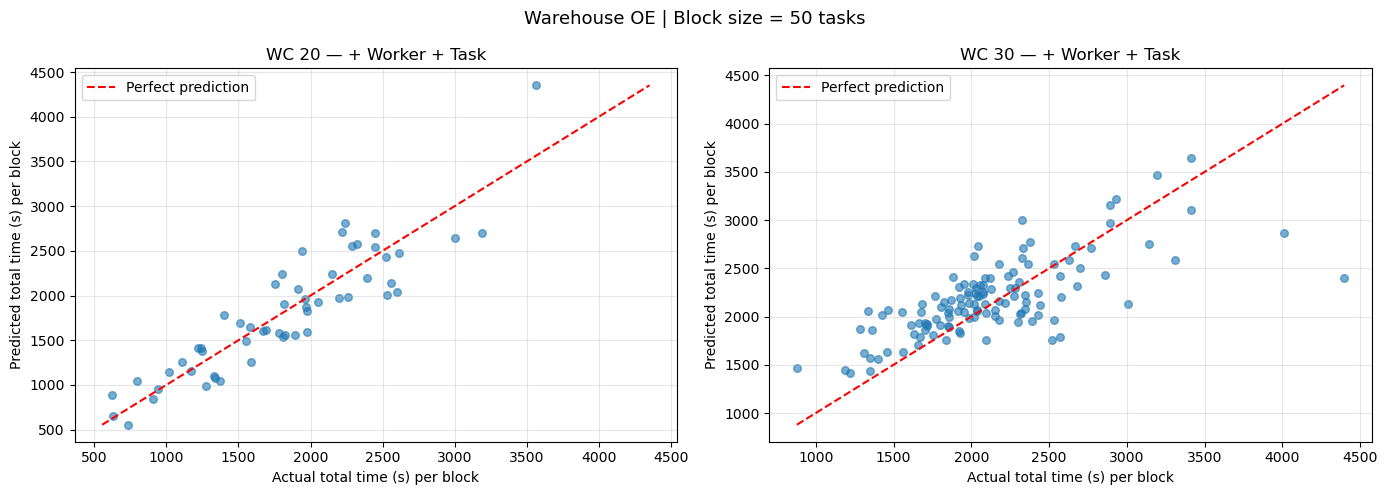

In [9]:
plot_model = "+ Worker + Task"
plot_df    = block_detail_df[block_detail_df["WorkCode"].isin(["20", "30"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, wc in zip(axes, ["20", "30"]):
    sub = plot_df[plot_df["WorkCode"] == wc]
    ax.scatter(sub["actual_time"], sub[plot_model], alpha=0.6, s=30)
    lims = [
        min(sub["actual_time"].min(), sub[plot_model].min()),
        max(sub["actual_time"].max(), sub[plot_model].max())
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual total time (s) per block")
    ax.set_ylabel("Predicted total time (s) per block")
    ax.set_title(f"WC {wc} — {plot_model}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Warehouse {WAREHOUSE} | Block size = {BLOCK_SIZE} tasks", fontsize=13)
plt.tight_layout()
plt.show()